In [110]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
BASE_PATH = '../dataset'
NASA_FOLDER = os.path.join(BASE_PATH, 'dataset_nasa')
EDA_OUTPUT_FOLDER = os.path.join(BASE_PATH, 'eda_outputs')

In [112]:
files = [
    f for f in os.listdir(NASA_FOLDER)
    if f.endswith(".csv")
]

print(f"Jumlah file NASA: {len(files)}") 

Jumlah file NASA: 514


In [113]:
all_nasa = []

for file in files:
    path = os.path.join(NASA_FOLDER, file)
    df = pd.read_csv(path)
    all_nasa.append(df)

nasa = pd.concat(all_nasa, ignore_index=True)

print(nasa.shape)    

(1501908, 8)


In [114]:
nasa.head()

,provinsi,kabupaten,latitude,longitude,date,PRECTOTCORR,T2M,RH2M
0,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-01,2.55,24.54,86.11
1,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-02,7.93,24.86,85.58
2,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-03,37.44,24.47,83.77
3,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-04,5.53,24.55,86.93
4,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-05,0.25,24.65,81.61


In [115]:
nasa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501908 entries, 0 to 1501907
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   provinsi     1501908 non-null  object 
 1   kabupaten    1501908 non-null  object 
 2   latitude     1501908 non-null  float64
 3   longitude    1501908 non-null  float64
 4   date         1501908 non-null  object 
 5   PRECTOTCORR  1501908 non-null  float64
 6   T2M          1501908 non-null  float64
 7   RH2M         1501908 non-null  float64
dtypes: float64(5), object(3)
memory usage: 91.7+ MB


In [116]:
nasa = nasa.rename(columns={
    'latitude': 'lat',
    'longitude': 'long',
    'PRECTOTCORR': 'curah_hujan',
    'T2M': 'temp_2m',
    'RH2M': 'kelembapan_2m',
})

In [117]:
nasa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501908 entries, 0 to 1501907
Data columns (total 8 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   provinsi       1501908 non-null  object 
 1   kabupaten      1501908 non-null  object 
 2   lat            1501908 non-null  float64
 3   long           1501908 non-null  float64
 4   date           1501908 non-null  object 
 5   curah_hujan    1501908 non-null  float64
 6   temp_2m        1501908 non-null  float64
 7   kelembapan_2m  1501908 non-null  float64
dtypes: float64(5), object(3)
memory usage: 91.7+ MB


In [118]:
nasa["date"] = pd.to_datetime(
    nasa["date"]
)

In [119]:
print('='*5, 'Tanggal Terkecil', '='*5)
nasa["date"].min()

===== Tanggal Terkecil =====


Timestamp('2018-01-01 00:00:00')

In [120]:
print('='*5, 'Tanggal Maksimum', '='*5)
nasa["date"].max()

===== Tanggal Maksimum =====


Timestamp('2025-12-31 00:00:00')

In [121]:
print("="*5+" Cek Kolom yang Kosong "+ "="*5)
print(nasa.isnull().sum())

===== Cek Kolom yang Kosong =====
provinsi         0
kabupaten        0
lat              0
long             0
date             0
curah_hujan      0
temp_2m          0
kelembapan_2m    0
dtype: int64


In [122]:
nasa[["curah_hujan", "temp_2m", "kelembapan_2m"]].describe()

,curah_hujan,temp_2m,kelembapan_2m
count,1.501908e+06,1.501908e+06,1.501908e+06
mean,7.157876e+00,2.587330e+01,8.434030e+01
std,1.088712e+01,2.286997e+00,6.746225e+00
min,0.000000e+00,7.740000e+00,4.307000e+01
25%,8.800000e-01,2.484000e+01,8.081000e+01
50%,3.590000e+00,2.624000e+01,8.539000e+01
75%,9.220000e+00,2.738000e+01,8.909000e+01
max,6.542700e+02,3.226000e+01,9.930000e+01


In [123]:
nasa.head()

,provinsi,kabupaten,lat,long,date,curah_hujan,temp_2m,kelembapan_2m
0,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-01,2.55,24.54,86.11
1,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-02,7.93,24.86,85.58
2,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-03,37.44,24.47,83.77
3,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-04,5.53,24.55,86.93
4,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-05,0.25,24.65,81.61


In [124]:
nasa.to_csv(os.path.join(EDA_OUTPUT_FOLDER, 'nasa_cleaned.csv'), index=False)

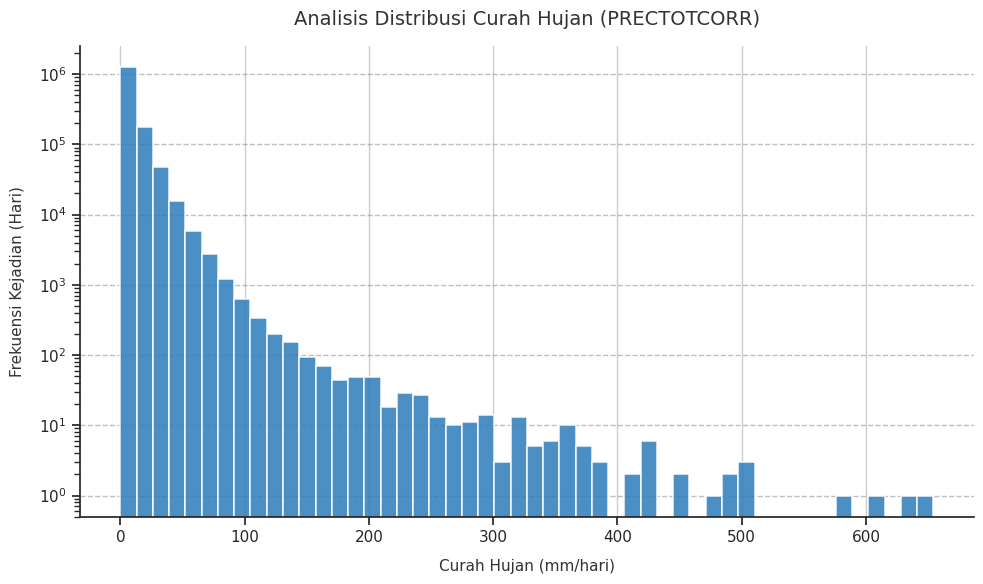

In [125]:
sns.set_theme(style="ticks")

plt.figure(figsize=(10, 6))

nasa["curah_hujan"].hist(
    bins=50, 
    color='#2b7bba', 
    edgecolor='white', 
    linewidth=1.2, 
    alpha=0.85,
    log=True
)   

plt.title(
    "Analisis Distribusi Curah Hujan (PRECTOTCORR)", 
    fontsize=14, 
    pad=15, 
    color='#333333'
)

plt.xlabel("Curah Hujan (mm/hari)", fontsize=11, labelpad=10, color='#333333')
plt.ylabel("Frekuensi Kejadian (Hari)", fontsize=11, labelpad=10, color='#333333')

plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_FOLDER, 'distribusi_curah_hujan.png'), dpi=300, bbox_inches='tight')
plt.show()

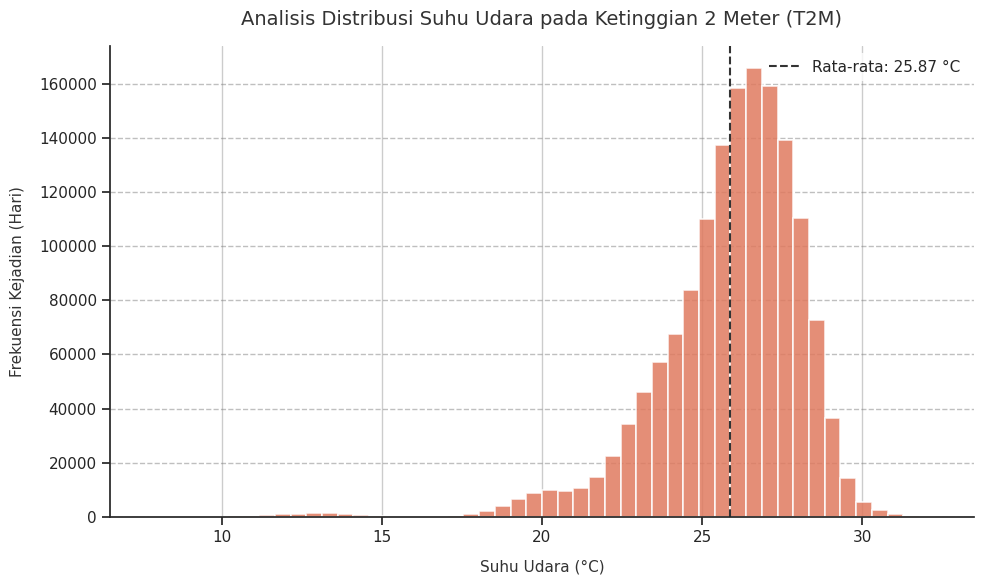

In [126]:
sns.set_theme(style="ticks")
plt.figure(figsize=(10, 6))

suhu_rata_rata = nasa["temp_2m"].mean()
nasa["temp_2m"].hist(
    bins=50, 
    color='#e07a5f', 
    edgecolor='white', 
    linewidth=1.2, 
    alpha=0.85
)

plt.axvline(
    suhu_rata_rata, 
    color='#333333', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Rata-rata: {suhu_rata_rata:.2f} °C'
)

plt.title(
    "Analisis Distribusi Suhu Udara pada Ketinggian 2 Meter (T2M)", 
    fontsize=14, 
    pad=15, 
    color='#333333'
)

plt.xlabel("Suhu Udara (°C)", fontsize=11, labelpad=10, color='#333333')
plt.ylabel("Frekuensi Kejadian (Hari)", fontsize=11, labelpad=10, color='#333333')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_FOLDER, 'distribusi_suhu_udara.png'), dpi=300, bbox_inches='tight')
plt.show()

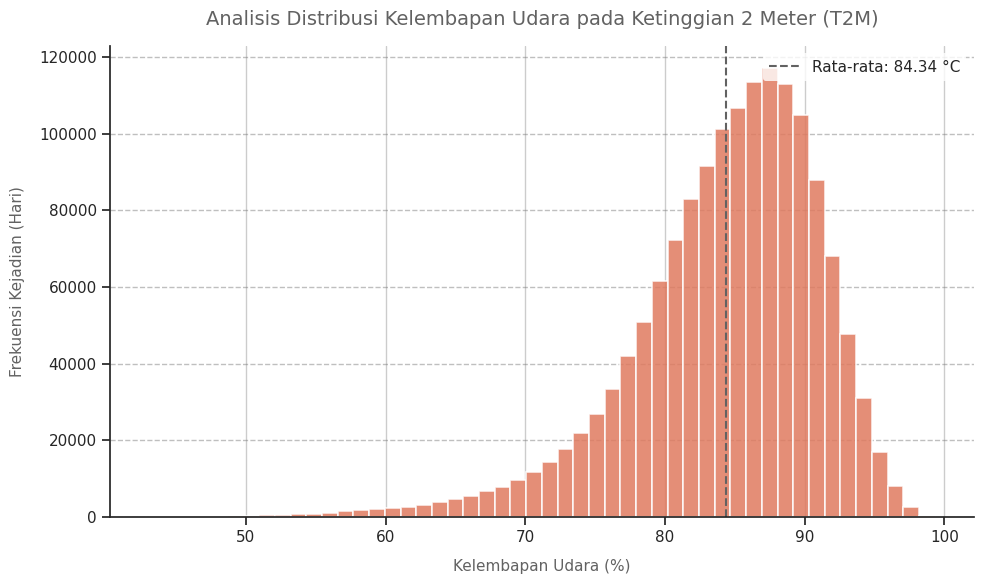

In [127]:
sns.set_theme(style="ticks")
plt.figure(figsize=(10, 6))

suhu_rata_rata = nasa["kelembapan_2m"].mean()
nasa["kelembapan_2m"].hist(
    bins=50, 
    color='#e07a5f', 
    edgecolor='white', 
    linewidth=1.2, 
    alpha=0.85
)

plt.axvline(
    suhu_rata_rata, 
    color='#626262', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Rata-rata: {suhu_rata_rata:.2f} °C'
)

plt.title(
    "Analisis Distribusi Kelembapan Udara pada Ketinggian 2 Meter (T2M)", 
    fontsize=14, 
    pad=15, 
    color="#626262"
)

plt.xlabel("Kelembapan Udara (%)", fontsize=11, labelpad=10, color='#626262')
plt.ylabel("Frekuensi Kejadian (Hari)", fontsize=11, labelpad=10, color='#626262')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_FOLDER, 'distribusi_kelembapan_udara.png'), dpi=300, bbox_inches='tight')
plt.show()